In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [13]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

def create_model():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

In [15]:
model_sgd = create_model()

model_sgd.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = model_sgd.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8127 - loss: 0.7164 - val_accuracy: 0.8977 - val_loss: 0.3541
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9063 - loss: 0.3277 - val_accuracy: 0.9187 - val_loss: 0.2781
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9233 - loss: 0.2704 - val_accuracy: 0.9271 - val_loss: 0.2459
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9332 - loss: 0.2333 - val_accuracy: 0.9394 - val_loss: 0.2160
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9413 - loss: 0.2067 - val_accuracy: 0.9435 - val_loss: 0.1971


In [16]:
model_rms = create_model()

model_rms.compile(
    optimizer='rmsprop',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_rms = model_rms.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9227 - loss: 0.2636 - val_accuracy: 0.9595 - val_loss: 0.1325
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9655 - loss: 0.1159 - val_accuracy: 0.9663 - val_loss: 0.1148
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9750 - loss: 0.0846 - val_accuracy: 0.9700 - val_loss: 0.1024
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9803 - loss: 0.0670 - val_accuracy: 0.9724 - val_loss: 0.1018
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9842 - loss: 0.0537 - val_accuracy: 0.9733 - val_loss: 0.1084


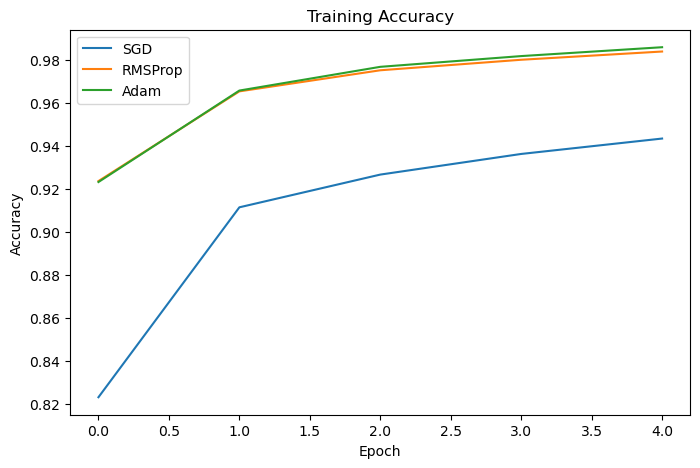

In [9]:
plt.figure(figsize=(8,5))

plt.plot(history_sgd.history['accuracy'], label='SGD')
plt.plot(history_rms.history['accuracy'], label='RMSProp')
plt.plot(history_adam.history['accuracy'], label='Adam')

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

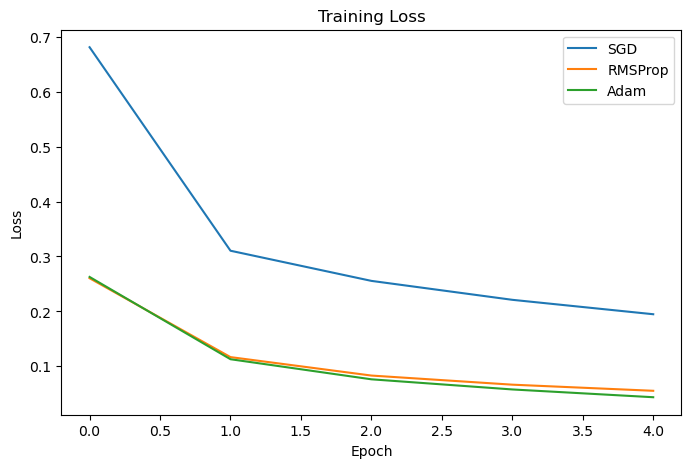

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history_sgd.history['loss'], label='SGD')
plt.plot(history_rms.history['loss'], label='RMSProp')
plt.plot(history_adam.history['loss'], label='Adam')

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [11]:
sgd_loss, sgd_acc = model_sgd.evaluate(x_test, y_test)

rms_loss, rms_acc = model_rms.evaluate(x_test, y_test)

adam_loss, adam_acc = model_adam.evaluate(x_test, y_test)

print("SGD Accuracy:", sgd_acc)
print("RMSProp Accuracy:", rms_acc)
print("Adam Accuracy:", adam_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9477 - loss: 0.1814
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9728 - loss: 0.1024
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9751 - loss: 0.0892
SGD Accuracy: 0.947700023651123
RMSProp Accuracy: 0.9728000164031982
Adam Accuracy: 0.9750999808311462


In [17]:
# Find the best optimizer
accuracies = {
    "SGD": sgd_acc,
    "RMSProp": rms_acc,
    "Adam": adam_acc
}

best_optimizer = max(accuracies, key=accuracies.get)

print("\nBest Optimizer:", best_optimizer)
print("Highest Accuracy:", round(accuracies[best_optimizer], 4))


Best Optimizer: Adam
Highest Accuracy: 0.9751


In [ ]:
#-------------------Summary---------------------------

#     A simple neural network was trained on the MNIST (Modified National Institute of Standards and Technology)
#     handwritten digit dataset using three optimizers: SGD, RMSProp, and Adam. 
#     Their accuracy and loss were compared. 
#     Adam achieved the highest accuracy and the lowest loss, making it the best optimizer for this classification task.